# Decision Tree on a 1D Regression Task

https://scikit-learn.org/stable/modules/tree.html#tree

https://scikit-learn.org/stable/auto_examples/tree/plot_tree_regression.html

In [10]:
import numpy as np
from sklearn import tree
import matplotlib.pyplot as plt

In [12]:
X = [[0, 0], [2, 2]]
y = [0.5, 2.5]
clf = tree.DecisionTreeRegressor()
clf = clf.fit(X, y)
clf.predict([[1, 1]])

array([0.5])

In [13]:
rng = np.random.RandomState(1)
X = np.sort(5 * rng.rand(80, 1), axis=0)
y = np.sin(X).ravel()
y[::5] += 3 * (0.5 - rng.rand(16))

This is the most critical part for teaching robust regression:

- y[::5]: Selects every 5th element in the array (indices 0, 5, 10, ..., 75). Since there are 80 items, this selects exactly 16 points.
- rng.rand(16): Generates 16 new random numbers between 0 and 1.
- 0.5 - ...: Shifts the range from to .
- 3 * ...: Scales the noise to be between and .
- +=: Adds this noise only to the selected 16 points.

Result: About 20% of the data points are now significant outliers that deviate sharply from the true sine wave.

In [19]:
y

array([-1.1493464 ,  0.09131401,  0.09668352,  0.13651039,  0.19403525,
       -0.12383814,  0.26365828,  0.41252216,  0.44546446,  0.47215529,
       -0.26319138,  0.49351799,  0.60530013,  0.63450933,  0.64144608,
        1.09900119,  0.66957978,  0.66968122,  0.73574834,  0.75072053,
        1.4926134 ,  0.8363043 ,  0.8532893 ,  0.87144496,  0.97060533,
       -0.20183403,  0.99131122,  0.99472837,  0.99825213,  0.99999325,
        1.21570343,  0.98769965,  0.98591565,  0.9159044 ,  0.91406986,
       -0.51669013,  0.8775346 ,  0.87063055,  0.86993408,  0.86523559,
        0.37007575,  0.78464608,  0.63168655,  0.53722799,  0.45801971,
        0.08075119,  0.43272116,  0.34115328,  0.26769953,  0.20730318,
        1.34959235, -0.17645185, -0.20918837, -0.24990778, -0.28068224,
       -1.63529379, -0.31247075, -0.31458595, -0.32442911, -0.34965155,
       -0.29371122, -0.46921115, -0.56401144, -0.57215326, -0.57488849,
       -0.95586361, -0.75923066, -0.78043659, -0.85808859, -0.94

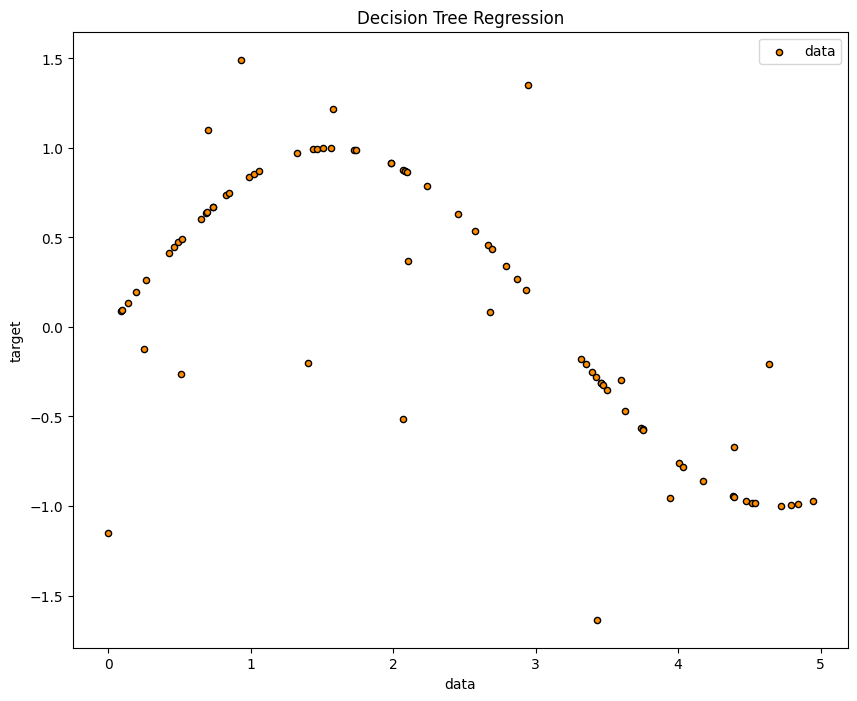

In [24]:
plt.figure(figsize=(10, 8))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()

In [25]:
from sklearn.tree import DecisionTreeRegressor
# Here we fit two models with different maximum depths

regr_1 = DecisionTreeRegressor(max_depth=2)
regr_2 = DecisionTreeRegressor(max_depth=5)
regr_1.fit(X, y)
regr_2.fit(X, y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_le

In [26]:
# predict

X_test = np.arange(0.0, 5.0, 0.01)[:, np.newaxis]
y_1 = regr_1.predict(X_test)
y_2 = regr_2.predict(X_test)

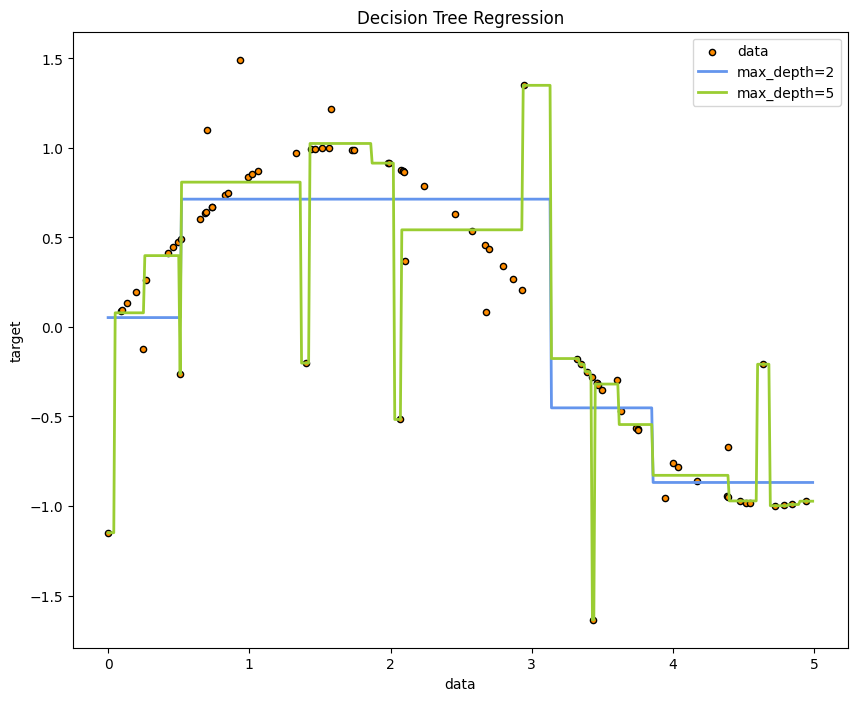

In [28]:
plt.figure(figsize=(10, 8))
plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="data")
plt.plot(X_test, y_1, color="cornflowerblue", label="max_depth=2", linewidth=2)
plt.plot(X_test, y_2, color="yellowgreen", label="max_depth=5", linewidth=2)
plt.xlabel("data")
plt.ylabel("target")
plt.title("Decision Tree Regression")
plt.legend()
plt.show()